# Customer Purchase Prediction Using Classification Algorithms

## Objective
Build classification models to predict whether a customer will purchase a product or service based on demographic and behavioral data.

### Workflow
1. Data Loading & Understanding
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. Model Building
5. Model Evaluation
6. Model Comparison
7. Conclusion


## Import Libraries



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


## Load Dataset

Explanation of this step is provided here for the project report.

In [3]:
df = pd.read_csv('customer_purchase_data.csv')

print('Dataset Shape:', df.shape)
display(df.head())
df.info()


Dataset Shape: (1500, 9)


,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
0,40,1,66120.267939,8,0,30.568601,0,5,1
1,20,1,23579.773583,4,2,38.240097,0,5,0
2,27,1,127821.306432,11,2,31.633212,1,0,1
3,24,1,137798.623120,19,3,46.167059,0,4,1
4,31,1,99300.964220,19,1,19.823592,0,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1500 non-null   int64  
 1   Gender              1500 non-null   int64  
 2   AnnualIncome        1500 non-null   float64
 3   NumberOfPurchases   1500 non-null   int64  
 4   ProductCategory     1500 non-null   int64  
 5   TimeSpentOnWebsite  1500 non-null   float64
 6   LoyaltyProgram      1500 non-null   int64  
 7   DiscountsAvailed    1500 non-null   int64  
 8   PurchaseStatus      1500 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 105.6 KB


## Check Missing Values



In [4]:
print(df.isnull().sum())

Age                   0
Gender                0
AnnualIncome          0
NumberOfPurchases     0
ProductCategory       0
TimeSpentOnWebsite    0
LoyaltyProgram        0
DiscountsAvailed      0
PurchaseStatus        0
dtype: int64


## Target Variable Distribution



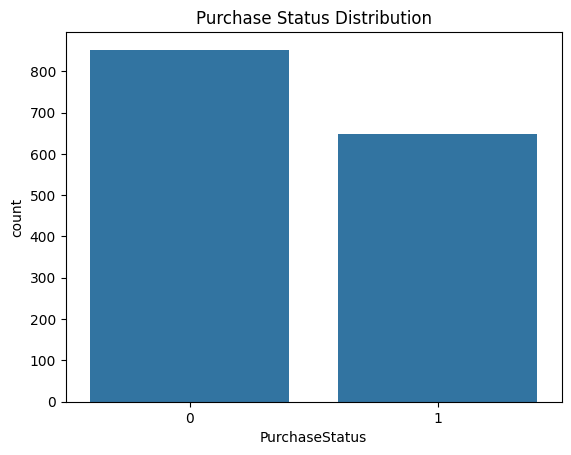

In [5]:
sns.countplot(x='PurchaseStatus', data=df)
plt.title('Purchase Status Distribution')
plt.show()

## Age Distribution



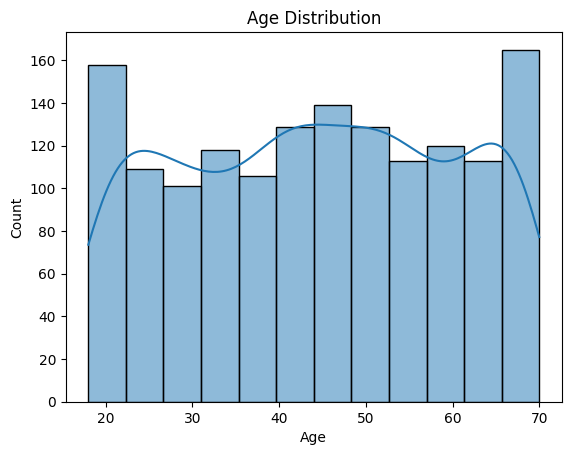

In [6]:
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')
plt.show()

## Annual Income Distribution



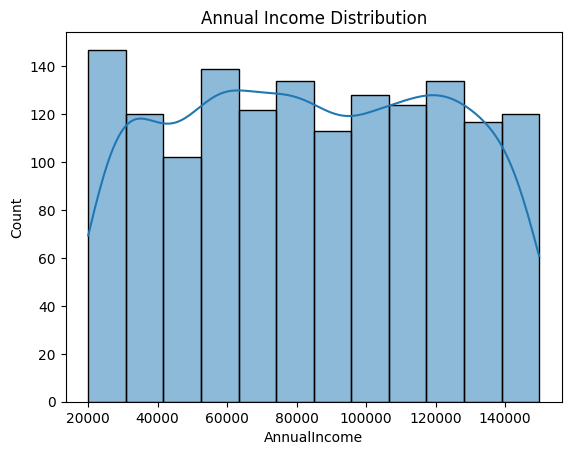

In [7]:
sns.histplot(df['AnnualIncome'], kde=True)
plt.title('Annual Income Distribution')
plt.show()

## Encode Categorical Variables



In [8]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['ProductCategory'] = le.fit_transform(df['ProductCategory'])

## Correlation Heatmap



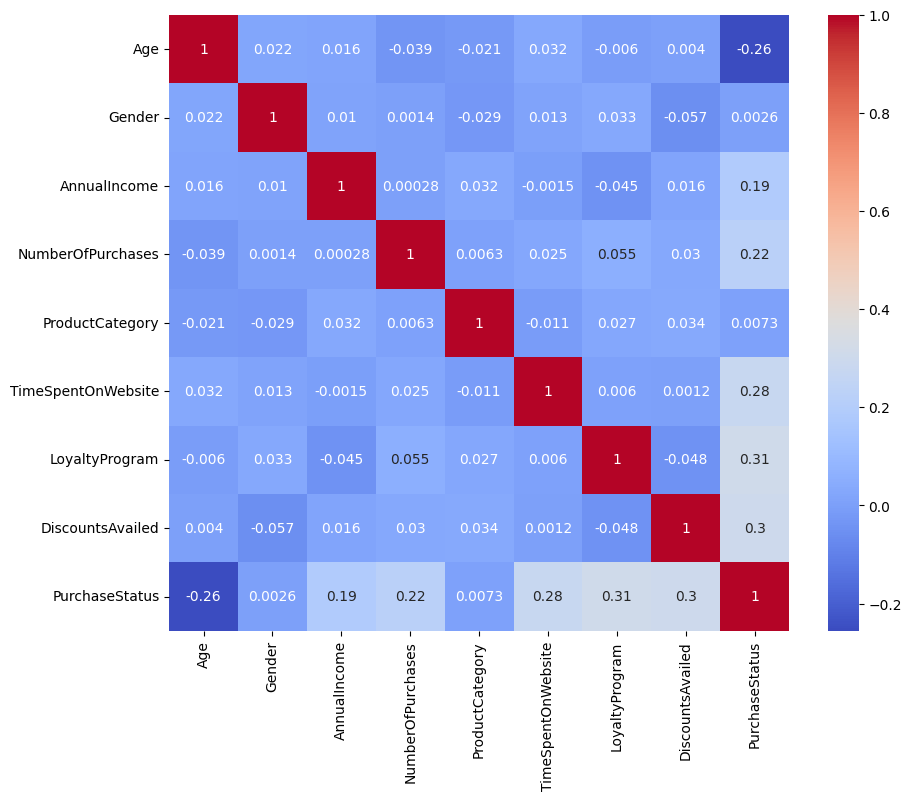

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

## Feature Selection



In [10]:
X = df.drop('PurchaseStatus', axis=1)
y = df['PurchaseStatus']

## Train Test Split



In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling



In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Logistic Regression



In [13]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87       172
           1       0.88      0.72      0.79       128

    accuracy                           0.84       300
   macro avg       0.85      0.82      0.83       300
weighted avg       0.84      0.84      0.83       300



## Decision Tree



In [14]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.89      0.94      0.91       172
           1       0.91      0.84      0.87       128

    accuracy                           0.90       300
   macro avg       0.90      0.89      0.89       300
weighted avg       0.90      0.90      0.90       300



## Random Forest



In [15]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96       172
           1       0.99      0.90      0.94       128

    accuracy                           0.95       300
   macro avg       0.96      0.95      0.95       300
weighted avg       0.96      0.95      0.95       300



## KNN



In [16]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86       172
           1       0.85      0.73      0.79       128

    accuracy                           0.83       300
   macro avg       0.84      0.82      0.83       300
weighted avg       0.84      0.83      0.83       300



## Model Comparison



In [20]:
results = pd.DataFrame({
    'Model':['Logistic Regression','Decision Tree','Random Forest','KNN'],
    'Accuracy':[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_knn)
    ],
    'Precision':[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_dt),
        precision_score(y_test,y_pred_rf),
        precision_score(y_test,y_pred_knn)
    ],
    'Recall':[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_dt),
        recall_score(y_test,y_pred_rf),
        recall_score(y_test,y_pred_knn)
    ],
    'F1 Score':[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_dt),
        f1_score(y_test,y_pred_rf),
        f1_score(y_test,y_pred_knn)
    ]
})

results.sort_values('Accuracy', ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.953333,0.991379,0.898438,0.942623
1,Decision Tree,0.896667,0.914530,0.835938,0.873469
2,Logistic Regression,0.836667,0.876190,0.718750,0.789700
3,KNN,0.833333,0.854545,0.734375,0.789916


## Confusion Matrix of Best Model



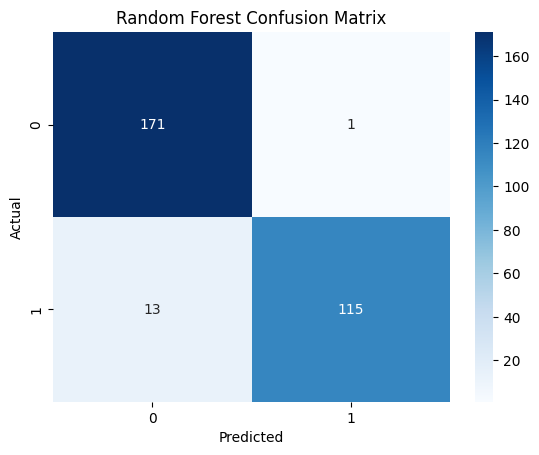

In [21]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Conclusion

Random Forest is expected to perform best for this customer purchase prediction problem.

### Key Insights
- Income influences purchasing behavior.
- Website engagement impacts conversion.
- Loyalty program participation improves purchase probability.
- Discounts encourage purchases.

